In [2]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# paths for the three dfs

df_jan_path = "/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-01.csv"
df_feb_path = "/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-02.csv"
df_mar_path = "/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-03.csv"

# load the dataframes

df_jan = dd.read_csv(df_jan_path, assume_missing=True)
df_feb = dd.read_csv(df_feb_path, assume_missing=True)
df_mar = dd.read_csv(df_mar_path, assume_missing=True)

In [4]:
df_jan

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
npartitions=26,,,,,,,,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


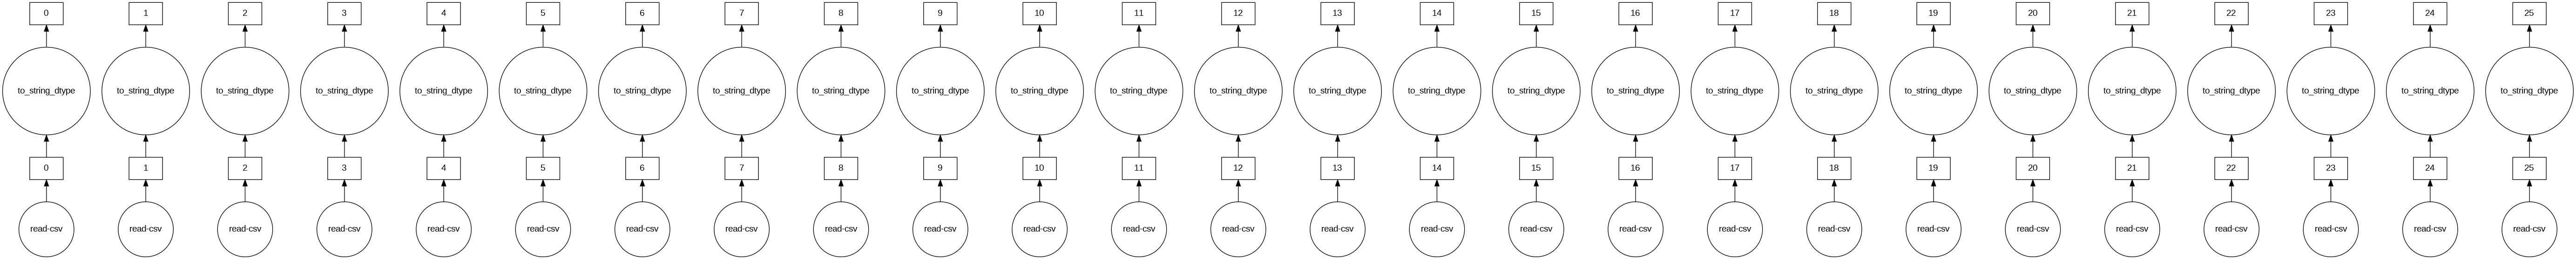

In [5]:
df_jan.visualize(tasks=True)

In [5]:
# Step 1 (memory-safe): read only needed columns, then concat

df_final = dd.concat([df_jan, df_feb, df_mar], axis=0)

In [6]:
# Step 2.1: parse datetime safely  --> string to datetime
df_final["tpep_pickup_datetime"] = dd.to_datetime(df_final["tpep_pickup_datetime"], errors="coerce")
df_final["tpep_dropoff_datetime"] = dd.to_datetime(df_final["tpep_dropoff_datetime"], errors="coerce")


In [7]:
# Step 2.2: minimal cleaning rules

df_final["trip_duration_min"] = (
    (df_final["tpep_dropoff_datetime"] - df_final["tpep_pickup_datetime"]).dt.total_seconds() / 60.0
)

clean_df = df_final[
    (df_final["tpep_pickup_datetime"].notnull()) &
    (df_final["tpep_dropoff_datetime"].notnull()) &
    (df_final["trip_duration_min"] > 0) &
    (df_final["trip_distance"] > 0) &
    (df_final["fare_amount"] > 0)
]


In [8]:
# Step 2.3: sanity check
clean_df[["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_duration_min", "trip_distance", "fare_amount"]].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_min,trip_distance,fare_amount
5,2016-01-01 00:00:00,2016-01-01 00:18:30,18.50,5.52,19.0
6,2016-01-01 00:00:00,2016-01-01 00:26:45,26.75,7.45,26.0
7,2016-01-01 00:00:01,2016-01-01 00:11:55,11.90,1.20,9.0
8,2016-01-01 00:00:02,2016-01-01 00:11:14,11.20,6.00,18.0
9,2016-01-01 00:00:02,2016-01-01 00:11:08,11.10,3.21,11.5


In [8]:
# check for missing values in the data

clean_df.isna().sum().compute()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
trip_duration_min        0
dtype: int64

In [9]:
# datatypes

df_final.dtypes

VendorID                         float64
tpep_pickup_datetime      datetime64[ns]
tpep_dropoff_datetime     datetime64[ns]
passenger_count                  float64
trip_distance                    float64
pickup_longitude                 float64
pickup_latitude                  float64
RatecodeID                       float64
store_and_fwd_flag       string[pyarrow]
dropoff_longitude                float64
dropoff_latitude                 float64
payment_type                     float64
fare_amount                      float64
extra                            float64
mta_tax                          float64
tip_amount                       float64
tolls_amount                     float64
improvement_surcharge            float64
total_amount                     float64
trip_duration_min                float64
dtype: object

In [10]:
# CHanging datatypes of few cols
float_cols = [
    "VendorID", "passenger_count", "trip_distance",
    "pickup_longitude", "pickup_latitude", "RatecodeID",
    "dropoff_longitude", "dropoff_latitude", "payment_type",
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "trip_duration_min"
]

for c in float_cols:
    if c in df_final.columns:
        df_final[c] = df_final[c].astype("float32")

if "store_and_fwd_flag" in df_final.columns:
    df_final["store_and_fwd_flag"] = df_final["store_and_fwd_flag"].astype("category")

df_final.dtypes


VendorID                        float32
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float32
trip_distance                   float32
pickup_longitude                float32
pickup_latitude                 float32
RatecodeID                      float32
store_and_fwd_flag             category
dropoff_longitude               float32
dropoff_latitude                float32
payment_type                    float32
fare_amount                     float32
extra                           float32
mta_tax                         float32
tip_amount                      float32
tolls_amount                    float32
improvement_surcharge           float32
total_amount                    float32
trip_duration_min               float32
dtype: object

In [ ]:
df_final.describe().compute()

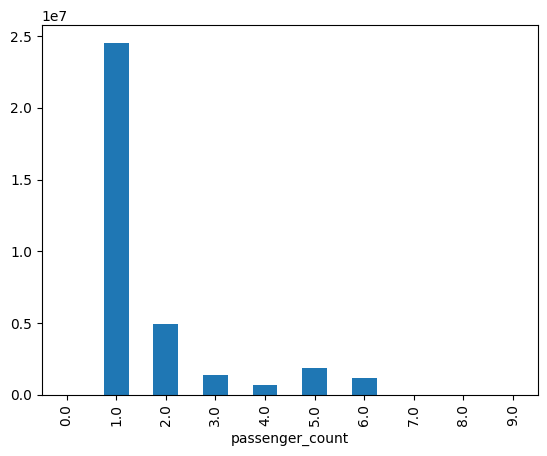

In [13]:
# countplot for passenger plot

passenger_count = df_final["passenger_count"].value_counts().compute()
passenger_count.sort_index().plot(kind="bar")
plt.show()

<Axes: ylabel='trip_distance'>

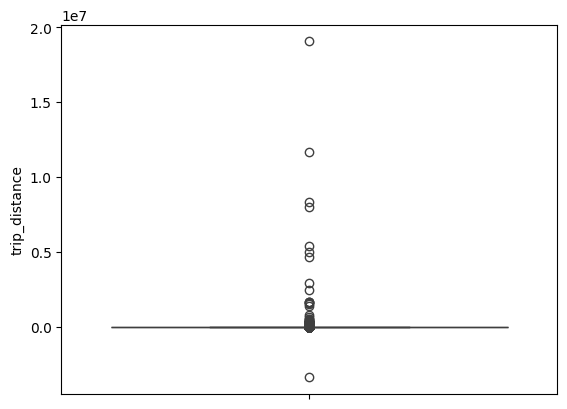

In [10]:
# boxplot for the trip distance

sns.boxplot(df_final.loc[:,"trip_distance"].compute())

In [11]:
# percentile values for trip distance

percentile_values = list(np.arange(0.1, 1.0, 0.1)) + list(np.arange(0.95, 1.01, 0.01))

for percentile in percentile_values:
    print(f"{int(percentile*100)}th percentile:",
          df_final['trip_distance'].quantile(q=percentile).compute())

10th percentile: 0.699999988079071
20th percentile: 0.9700000286102295
30th percentile: 1.2300000190734863
40th percentile: 1.559999942779541
50th percentile: 1.9299999475479126
60th percentile: 2.490000009536743
70th percentile: 3.2699999809265137
80th percentile: 4.599999904632568
90th percentile: 8.300000190734863
95th percentile: 12.100000381469727
96th percentile: 14.680000305175781
97th percentile: 16.90999984741211
98th percentile: 17.950000762939453
99th percentile: 19.375499916076542
100th percentile: 19072628.0


ValueError: percentiles should all be in the interval [0, 1]

<Axes: ylabel='fare_amount'>

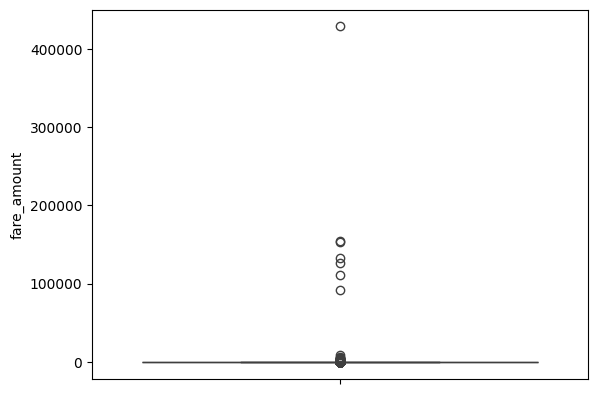

In [12]:
# boxplot for the fare amount

sns.boxplot(df_final.loc[:,"fare_amount"].compute())

In [13]:
# percentile values for fare amount

percentile_values = list(np.arange(0.1, 1.0, 0.1)) + [0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
percentile_values

for percentile in percentile_values:
    print(f"The fare amount value for {int(percentile * 100)}th percentile is {df_final['fare_amount'].quantile(q=percentile).compute()}")

The fare amount value for 10th percentile is 5.0
The fare amount value for 20th percentile is 6.0
The fare amount value for 30th percentile is 7.5
The fare amount value for 40th percentile is 8.5
The fare amount value for 50th percentile is 10.0
The fare amount value for 60th percentile is 11.5
The fare amount value for 70th percentile is 14.0
The fare amount value for 80th percentile is 18.0
The fare amount value for 90th percentile is 27.0
The fare amount value for 95th percentile is 40.0
The fare amount value for 96th percentile is 49.5
The fare amount value for 97th percentile is 52.0
The fare amount value for 98th percentile is 52.0
The fare amount value for 99th percentile is 52.0
The fare amount value for 100th percentile is 429496.71875


<Axes: ylabel='trip_duration_min'>

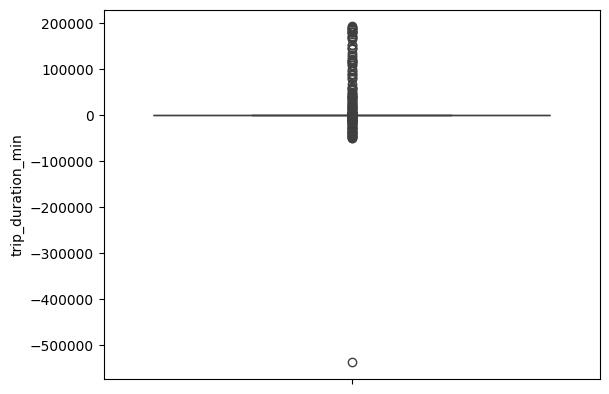

In [14]:
sns.boxplot(df_final.loc[:,"trip_duration_min"].compute())

In [16]:
# percentile values for trip_duration min

percentile_values = list(np.arange(0.1, 1.0, 0.1)) + [0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
percentile_values

for percentile in percentile_values:
    print(f"The fare amount value for {int(percentile * 100)}th percentile is {df_final['trip_duration_min'].quantile(q=percentile).compute()}")

The fare amount value for 10th percentile is 4.416666507720947
The fare amount value for 20th percentile is 6.233333110809326
The fare amount value for 30th percentile is 7.933333396911621
The fare amount value for 40th percentile is 9.766666412353516
The fare amount value for 50th percentile is 11.783333778381348
The fare amount value for 60th percentile is 14.216666221618652
The fare amount value for 70th percentile is 17.316667556762695
The fare amount value for 80th percentile is 21.75
The fare amount value for 90th percentile is 29.850000381469727
The fare amount value for 95th percentile is 40.16666793823242
The fare amount value for 96th percentile is 43.95000076293945
The fare amount value for 97th percentile is 48.900001525878906
The fare amount value for 98th percentile is 56.053332519531445
The fare amount value for 99th percentile is 69.08333587646484
The fare amount value for 100th percentile is 192313.390625


In [14]:
location_subset = df_final[['pickup_latitude','pickup_longitude', 
                           'dropoff_latitude','dropoff_longitude']]

location_subset

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
npartitions=82,,,,
,float32,float32,float32,float32
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


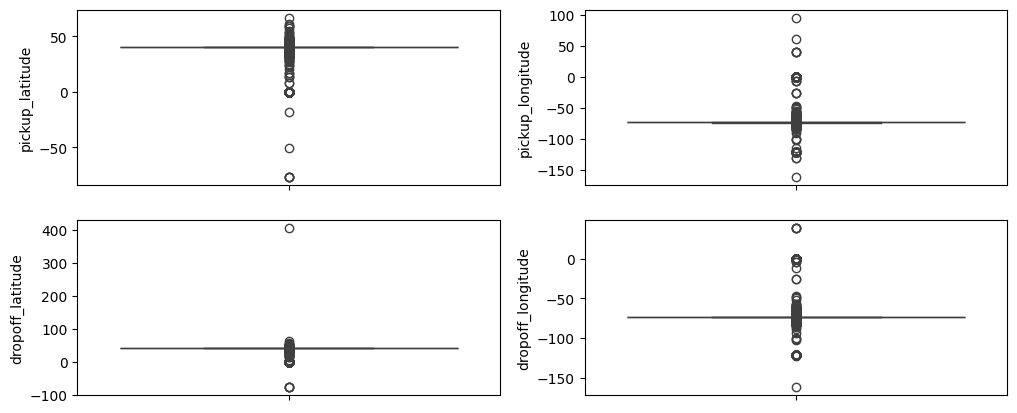

In [18]:
# boxplots for location based columns

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
for i in range(4):
    if i <= 1:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax1[i])
    else:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax2[i - 2])

<Axes: xlabel='count', ylabel='store_and_fwd_flag'>

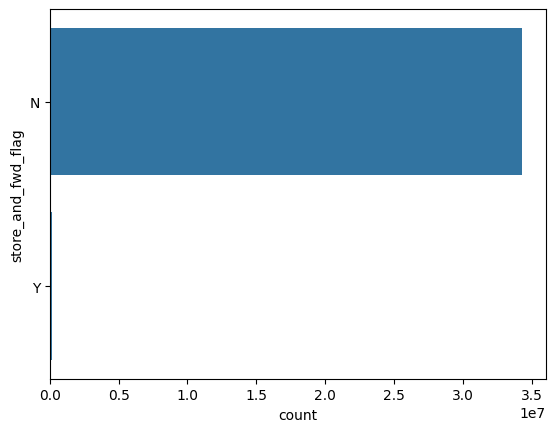

In [19]:
# Store and Fwd Flag

sns.countplot(df_final["store_and_fwd_flag"].compute())

In [12]:
# create new columns

df_final["pickup_months"] = df_final["tpep_pickup_datetime"].dt.month
df_final["pickup_day_of_week"] = df_final["tpep_pickup_datetime"].dt.dayofweek
df_final["pickup_hour"] = df_final["tpep_pickup_datetime"].dt.hour

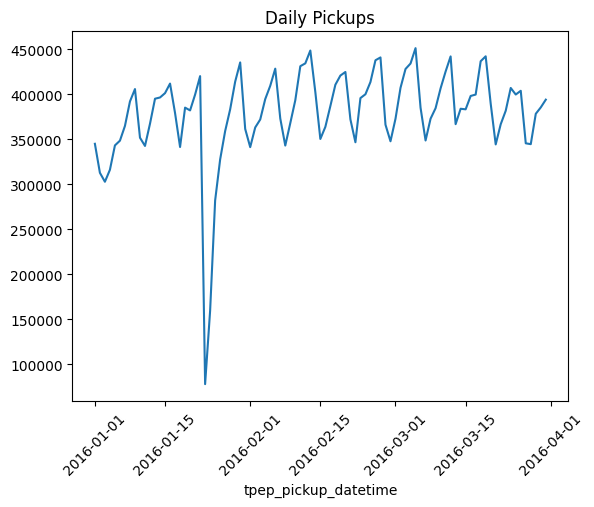

In [13]:
# plot the number of pickups

pickups_every_1_days = (
    df_final[["tpep_pickup_datetime"]]
    .dropna(subset=["tpep_pickup_datetime"])
    .set_index("tpep_pickup_datetime")
    .resample("1D")
    .size()
    .compute()
)

sns.lineplot(x=pickups_every_1_days.index, y=pickups_every_1_days.values)
plt.xticks(rotation=45)
plt.title("Daily Pickups")
plt.show()

In [15]:
# pickups for each hour of the day

pickups_each_hour = (
    df_final
    .groupby(["pickup_hour", "pickup_day_of_week"])
    .size()
    .compute()
    .reset_index(name="Number of Pickups")
)

pickups_each_hour.head()

,pickup_hour,pickup_day_of_week,Number of Pickups
0,4,2,29498
1,4,3,32480
2,5,2,49844
3,6,2,136330
4,6,3,138392


In [25]:
pickups_each_hour = pickups_each_hour.reset_index()

pickups_each_hour.rename(columns={"VendorID":"Number of Pickups"},inplace=True)

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

replacement_mapper = {k:v for k,v in enumerate(day_names)}

replacement_mapper

{0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

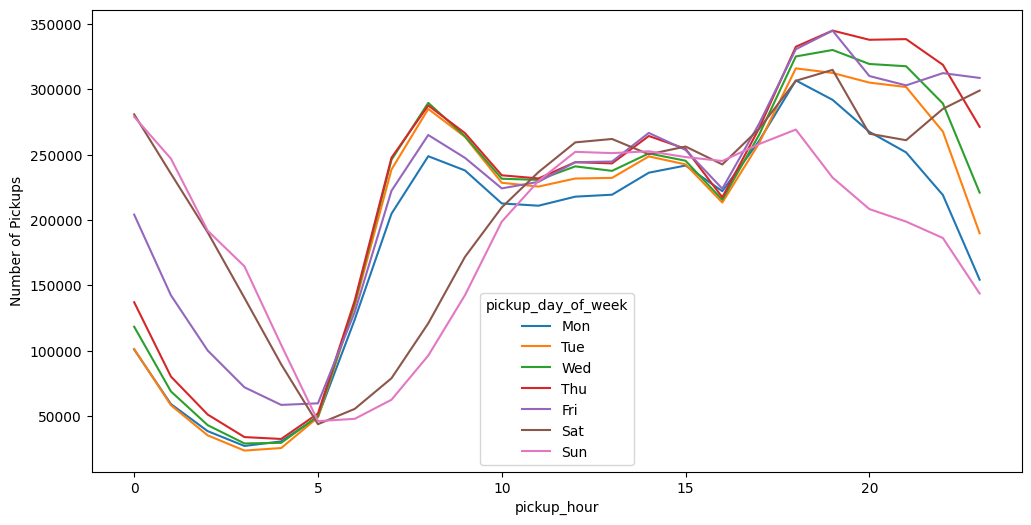

In [26]:
pickups_each_hour.replace({"pickup_day_of_week":replacement_mapper},inplace=True)

# plot the lineplot

fig = plt.figure(figsize=(12,6))

sns.lineplot(pickups_each_hour, x="pickup_hour", y="Number of Pickups", 
             hue="pickup_day_of_week",hue_order=day_names)

plt.show()

## Creating zones interval for Arima/Sarima/Prophet models

In [16]:
# Use cleaned data for all downstream EDA
# ...existing code...
clean_df["pickup_months"] = clean_df["tpep_pickup_datetime"].dt.month
clean_df["pickup_day_of_week"] = clean_df["tpep_pickup_datetime"].dt.dayofweek
clean_df["pickup_hour"] = clean_df["tpep_pickup_datetime"].dt.hour
# ...existing code...

In [17]:
# ...existing code...

# Build zone_id safely
zone_df = clean_df[
    ["tpep_pickup_datetime", "pickup_latitude", "pickup_longitude",
     "trip_distance", "fare_amount", "trip_duration_min"]
].copy()

zone_df["lat_bin"] = zone_df["pickup_latitude"].round(2)
zone_df["lon_bin"] = zone_df["pickup_longitude"].round(2)
zone_df["zone_id"] = zone_df["lat_bin"].astype("string") + "_" + zone_df["lon_bin"].astype("string")

# Aggregate 1: means
zone_stats_pd = (
    zone_df.groupby("zone_id")
    .agg({
        "trip_distance": "mean",
        "fare_amount": "mean",
        "trip_duration_min": "mean"
    })
    .rename(columns={
        "trip_distance": "zone_avg_trip_distance",
        "fare_amount": "zone_avg_fare",
        "trip_duration_min": "zone_avg_duration_min"
    })
    .compute()
    .reset_index()
)

# Aggregate 2: counts
zone_counts_pd = (
    zone_df.groupby("zone_id")
    .size()
    .compute()
    .reset_index(name="zone_total_pickups")
)

# Merge in pandas (stable)
zone_features = zone_stats_pd.merge(zone_counts_pd, on="zone_id", how="left")

zone_features.sort_values("zone_total_pickups", ascending=False).head(20)
# ...existing code...

,zone_id,zone_avg_trip_distance,zone_avg_fare,zone_avg_duration_min,zone_total_pickups
300,40.76_-73.97,2.450951,10.801446,14.056462,2111856
2366,40.75_-73.99,2.727980,11.253372,15.301053,2102891
301,40.76_-73.98,2.572961,11.910529,15.804504,1849074
3,40.75_-73.98,2.576258,11.063191,14.420042,1710063
1452,40.74_-73.99,3.902939,10.606939,14.233464,1555377
1755,40.76_-73.99,2.818830,11.674309,14.945925,1547690
1451,40.73_-73.99,3.272118,11.013995,15.096505,1223634
875,40.77_-73.96,1.981523,9.739630,12.724777,1197193
2674,40.77_-73.98,2.552782,10.820519,14.400764,1096118
1758,40.73_-74.0,18.489474,11.127948,15.094981,1035242


In [ ]:
# each zone’s peak pickup hour

# What: find the busiest hour for each zone
# Why: captures zone-specific temporal behavior (business vs residential vs transit patterns)

zone_hour_pd = (
    zone_df.assign(pickup_hour=zone_df["tpep_pickup_datetime"].dt.hour)
    .groupby(["zone_id", "pickup_hour"])
    .size()
    .compute()
    .reset_index(name="pickup_count")
)

zone_peak_hour = (
    zone_hour_pd.sort_values(["zone_id", "pickup_count"], ascending=[True, False])
    .drop_duplicates("zone_id")
    .rename(columns={"pickup_hour": "zone_peak_hour"})
    [["zone_id", "zone_peak_hour"]]
)

zone_features = zone_features.merge(zone_peak_hour, on="zone_id", how="left")
zone_features.head()